In [8]:
import sys
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PyMPDATA-examples')

In [1]:
import numpy as np
import numba
numba.set_num_threads(1)

import matplotlib.pyplot as plt
from open_atmos_jupyter_utils import show_plot, show_anim
import os
os.environ['NUMBA_THREADING_LAYER']='omp'
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions # boundry conditions dla rownan rozniczkowych

In [3]:
class ShallowWaterEquationsIntegrator:
    def __init__(self, *, bathymetry: np.ndarray, 
                 h_initial: np.ndarray, 
                 uh_initial: np.ndarray|None = None, 
                 vh_initial: np.ndarray|None = None, 
                 options:   Options|None    = None):
        """ initializes the solvers for a given initial condition of `h` at t=0 """
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y, grid = 0, 1, h_initial.shape
        if uh_initial is None: uh_initial = np.zeros(grid)
        if vh_initial is None: vh_initial = np.zeros(grid)
        stepper = Stepper(options=options, grid=grid)
        bc_x = boundary_conditions.Constant(value=0)   # left/right wells
        bc_y = boundary_conditions.Extrapolated()      # inflow/outflow in y

        bc = (bc_x, bc_y)  # or [bc_x, bc_y]

        kwargs = {
            'boundary_conditions': bc,
            'halo': options.n_halo,
        }
        advectees = {
            "h": ScalarField(h_initial, **kwargs),
            "uh": ScalarField(uh_initial, **kwargs),
            "vh": ScalarField(vh_initial, **kwargs),
        }
        self.advector = VectorField((
                np.zeros((grid[X] + 1, grid[Y])),
                np.zeros((grid[X], grid[Y] + 1))
            ), **kwargs
        )
        self.solvers = { k: Solver(stepper, v, self.advector) for k, v in advectees.items() }
        self.bathymetry = bathymetry

    def __getitem__(self, key):
        """ returns `key` advectee field of the current solver state """
        return self.solvers[key].advectee.get()
    
    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        """ applies half of the source term in the given direction """
        self[key][:] -= .5 * g_times_dt_over_dxy * self['h'] * np.gradient(self['h']-self.bathymetry, axis=axis)

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        """ computes the Courant number component from fluid column height and momenta fields """
        velocity = np.where(mask, np.nan, 0)
        momentum = self[key]
        np.divide(momentum, self['h'], where=mask, out=velocity)

        all = slice(None, None) 
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)

        velocity_at_cell_boundaries = velocity[( 
            (all_but_last, all),
            (all, all_but_last),
        )[axis]] + np.diff(velocity, axis=axis) / 2 
        courant_number = self.advector.get_component(axis)[(
            (all_but_first_and_last, all),
            (all, all_but_first_and_last)
        )[axis]]
        courant_number[:] = velocity_at_cell_boundaries * dt_over_dxy[axis]
        if np.amax(np.abs(courant_number)) > 1:
            print("C>1!")
            return 0
        return 1

    def __call__(self, *, nt: int, g: float, dt_over_dxy: tuple, outfreq: int, eps: float=1e-7):  # tuple jest poukladany i niezmienialny, ale moze miec rozne typy w sobie
        """ integrates `nt` timesteps and returns a dictionary of solver states recorded every `outfreq` step[s] """
        output = {k: [] for k in self.solvers.keys()}
        courant_ok = 1

        for it in range(nt + 1): 
            if not courant_ok:
                print(f"At it = {it}")
                break
            if it != 0:
                mask = self['h'] > eps
                for axis, key in enumerate(("uh", "vh")):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(n_steps=1)
                for axis, key in enumerate(("uh", "vh")):
                    if not courant_ok:
                        break
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(n_steps=1)
                    courant_ok = min(self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy), courant_ok)
                    # self._update_courant_numbers(axis=axis, key=key, mask=mask, dt_over_dxy=dt_over_dxy)
            if it % outfreq == 0:
                for key in self.solvers.keys():
                    output[key].append(self[key].copy())
        return output

In [4]:
def gaussian(x, *, amp=1.0, mu=0.0, sigma=1.0):
    return amp*np.exp(-0.5 * (x-mu)**2 / sigma**2)

In [5]:
class waveReflection:
    def __init__(self,*,
                 grid:tuple[int,int], 
                 well_center:float|None = None,
                 well_depth:float = 1,
                 well_width:float = 1,
                 wave_center:float|None = None,
                 wave_height:float = 0.025,
                 wave_width:float = 1,
                 H0:float = 1.0,
                 g:float = 10.0
                 ) -> None:
        if H0<=wave_height:
            raise ValueError("Wave fronts cannot exceed 0; H0-wave_height<0")
        X, Y = 0, 1

        if well_center is None:
            well_center = grid[X]//2
        else:
            if well_center>grid[X]:
                raise ValueError("Well center outside of grid")
        if wave_center is None:
            wave_center = grid[X]//4
        else:
            if wave_center>grid[X]:
                raise ValueError("Wave center outside of grid")
        
        self.grid = grid
        self.well_center, self.well_depth, self.well_width = well_center, well_depth, well_width
        self.wave_center, self.wave_height, self.wave_width = wave_center, wave_height, wave_width
        self.H0, self.g = H0, g

        self.xi, self.yi = np.indices(grid)

        self.bathymetry = gaussian(self.xi, amp = self.well_depth, mu = self.well_center, sigma = self.well_width)
        waveshape = gaussian(self.xi, amp = self.wave_height, mu = self.wave_center, sigma = self.wave_width)
        self.h_initial = waveshape + self.bathymetry + self.H0

        U = np.sqrt(self.g * self.H0)
        u = waveshape * U / self.H0
        self.uh_initial = u * self.h_initial
        self.vh_initial = np.zeros(grid)
        self.output = None
        self.dt_over_dx = None
        self.out_freq = None
        
    def plot_initial(self):
        fig, axs = plt.subplots(2, 2, figsize = (8,6))
        titles = [[r'$h(x,y;t=0)$', r'$b(x,y;t=0)$'],
                  [r'$(h-b)(x,y;t=0)$', r'$\vec v(x,y;t=0)$']]
        nobath = self.h_initial-self.bathymetry
        # print(nobath.min(), nobath.max())
        np.savetxt('bla.csv', self.bathymetry)
        vmin, vmax = self.bathymetry.min(), self.h_initial.max()

        cs1 = axs[0,0].contourf(self.h_initial.T, vmin=vmin, vmax = vmax, levels=30)
        axs[0,1].contourf(self.bathymetry.T, vmin=vmin, vmax = vmax, levels=30)
        axs[1,0].contourf(nobath.T, vmin=vmin, vmax = vmax, levels=30)
        axs[1,1].quiver(self.xi.T, self.yi.T, self.uh_initial.T, self.vh_initial.T, scale = 3)
        for i in [0,1]:
            for j in [0,1]:
                axs[i,j].set_title(titles[i][j])
                axs[i,j].set_xlabel(r"$x$")
                axs[i,j].set_ylabel(r"$y$")
                # pass
        plt.tight_layout()
        cbar = fig.colorbar(cs1, ax = axs, location='right')
        cbar.set_label('Field value')

    def run(self,*,
            nt, 
            dt_over_dxy=(.1, .1), 
            outfreq=3
            ):
        self.dt_over_dx = dt_over_dxy[0]
        self.out_freq = outfreq
        self.output = ShallowWaterEquationsIntegrator(
            h_initial=self.h_initial, uh_initial=self.uh_initial, bathymetry=self.bathymetry
        )(
            nt=nt, g=self.g, dt_over_dxy=dt_over_dxy, outfreq=outfreq
        )
    def fields_at_xy(self, indx = None, indy=None):        
        if indx is None:
            indx = self.grid[0] * 3 // 8
        if indy is None:
            indy = self.grid[1]//2
        if self.output is None:
            raise ValueError("Output has not been generated yet")
        
        h = self.output['h']
        uh = self.output['uh']
        length = len(uh)
        uh_center =np.zeros([length]) 
        h_center = np.zeros([length])
        for i in range(length):
            uh_center[i] = uh[i][indx, indy]
            h_center[i] = h[i][indx, indy]
        u_center = uh_center/h_center

        return h_center, u_center

    


        
    def plot_h(self, frame):
        if self.output is None:
            raise ValueError("Output has not been generated yet")
        
        psi = (self.output['h'][frame]-self.bathymetry)
        fig = plt.figure(figsize=(5, 3))
        plt.title(f"t/dt = {frame}")
        vmin = self.H0 - 1.2* self.wave_height
        vmax = self.H0 + 1.2* self.wave_height
        plt.imshow(psi, vmin = vmin, vmax = vmax)
        plt.xlabel('x/Δx')
        plt.ylabel('y/Δy')
        plt.colorbar()
        return fig
    
    
    def animate(self, fname):
        if self.output is None:
            raise ValueError("Output has not been generated yet")
        
        length = len(self.output['h'])
        show_anim(self.plot_h, range(0,length, 1), gif_file = fname)

    def R_factor(self, *, indx = None, indy = None):
        if indx is None:
            indx = self.grid[0] * 3 // 8
        if indy is None:
            indy = self.grid[1]//2
        h, _ = self.fields_at_xy(indx=indx, indy=indy)
        x_over_dx = self.well_center - self.wave_center
        c = np.sqrt(self.g*self.H0) * self.dt_over_dx
        t_over_dt = int(x_over_dx/c/self.out_freq + self.wave_width) # bufor aby cala fala sie znalazla wewnatrz zakresu
        h_wave = np.abs(h[:t_over_dt]-self.H0 - self.bathymetry[indx, indy])
        h_reflection = np.abs(h[t_over_dt:]-self.H0 - self.bathymetry[indx, indy])
        wave_H0 = h_wave.max()
        ref_H0 = h_reflection.max()
        return t_over_dt, ref_H0/wave_H0

In [21]:
def plot_output(w:waveReflection, *, fname1, fname2, indx = None, indy = None):
        if w.output is None:
            raise ValueError("Output has not been generated yet")  
        if indx is None:
            indx = w.grid[0] * 3 // 8
        if indy is None:
            indy = w.grid[1]//2
        
        post_reflection = w.output['h'][-1]-w.bathymetry


        t_over_dt, R_factor = w.R_factor(indx=indx, indy=indy)
        R_f_perc = 100 * R_factor
        # print(f"wsp. odbicia R = {R_f_perc:.0f}%")

        fig, ax_big = plt.subplots(1, 1, figsize=(10,5))

        ax_big.contourf(post_reflection.T, cmap='viridis', levels=30)
        ax_big.set_title(rf'$(h-b)(x,y;t/Δt=-1),\;\sigma_{{well}}={w.well_width}, Amp_{{well}}={w.well_depth}$, $R$ = {R_f_perc}%')
        ax_big.set_ylabel("y/Δy")
        ax_big.set_xlabel("x/Δx")



        h_center, u_center = w.fields_at_xy(indx=indx, indy=indy)
        plt.savefig(fname1)

        plt.clf()
        fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
        fig.suptitle(rf"$\sigma_{{well}}={w.well_width}, Amp_{{well}}={w.well_depth}$, $R$ = {R_f_perc:.0f}%", fontsize=16)
        # fig.
        ax1.plot(h_center, label=rf'$h$')
        ax1.set_xlabel(f"$t/Δt$")
        ax1.set_ylabel(f"$h$")
        ax1.set_title(rf"$h(x={indx}Δx,y={indy}Δy;t)$")
        ax1.grid()
        # , 

        ax1.fill_betweenx([h_center.min(), h_center.max()],0,t_over_dt, alpha=0.3, color = 'green', label = 'fala')
        ax1.fill_betweenx([h_center.min(), h_center.max()],t_over_dt,len(w.output['h']), alpha=0.3, color = 'red', label = 'teor. odbicie')
        ax1.legend()


        ax2.plot(u_center, color='purple', label=f'$v$')
        ax2.set_xlabel(f"$t/Δt$")
        ax2.set_ylabel(rf"$v$")
        ax2.set_title(rf"$v(x={indx}Δx,y={indy}Δy;t)$")
        ax2.fill_betweenx([u_center.min(), u_center.max()],0,t_over_dt, alpha=0.3, color = 'green', label = 'fala')
        ax2.fill_betweenx([u_center.min(), u_center.max()],t_over_dt,len(w.output['h']), alpha=0.3, color = 'red', label = 'teor. odbicie')
        ax2.legend()
        ax2.grid()

        fig.tight_layout()

        plt.savefig(fname2)

In [14]:
wave = waveReflection(grid = (200,50), well_width=3, well_depth=3, wave_width=5)

In [15]:
wave.run(nt = 500)

<Figure size 1000x500 with 0 Axes>

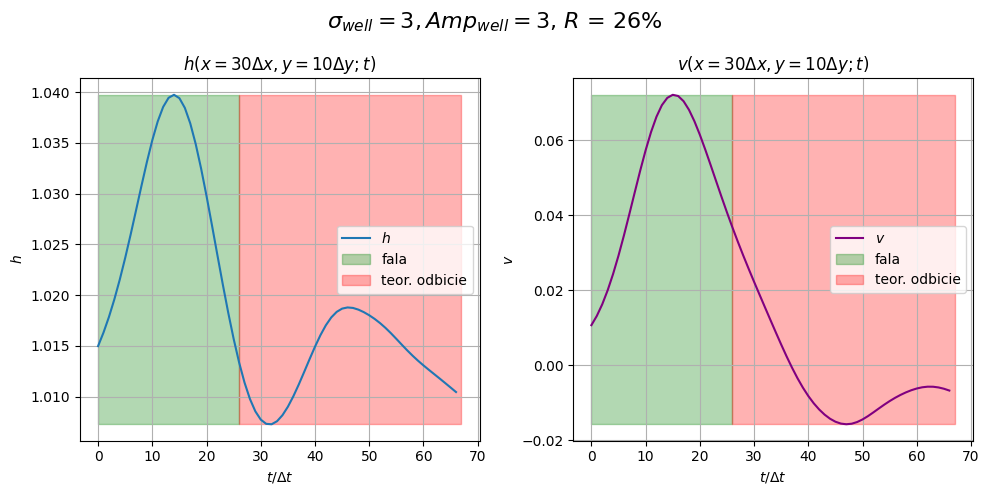

In [23]:
plot_output(wave, fname1 = 'shape.pdf', fname2 = 'wave_change.pdf')

In [17]:
%%capture
wave.animate('reflection.gif');

In [18]:
widths = np.arange(1,31)/3
amps = 9.0/widths
# print(ww, wa)
Rs = []
for w, a in zip(widths, amps):
    # print(f'wid = {w}; amp = {a}')
    wave = waveReflection(grid = (200,50), well_depth=a, well_width=w, wave_width=5)
    wave.run(nt = 500)
    _, R = wave.R_factor()
    Rs.append(R)

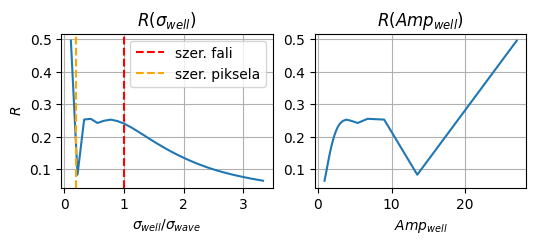

In [19]:
fig, axs = plt.subplots(1,2, figsize=(6,2))
Rsa = np.array(Rs)
axs[0].plot(widths/3, Rs)
axs[1].plot(amps, Rs)
axs[0].grid()
axs[1].grid()

axs[0].set_title(r"$R(\sigma_{well}$)")
axs[0].set_xlabel(r"$\sigma_{well}/\sigma_{wave}$")
axs[0].set_ylabel(r"$R$");
axs[0].axvline(x=1, label='szer. fali', color='red', linestyle='--')
axs[0].axvline(x=0.2, label='szer. piksela', color='orange', linestyle='--')
axs[0].legend()

axs[1].set_title(r"$R(Amp_{well})$")
axs[1].set_xlabel(r"$Amp_{well}$")

plt.savefig("R.pdf")
# axs[1].set_ylabel(r"$R$");

<Figure size 1000x500 with 0 Axes>

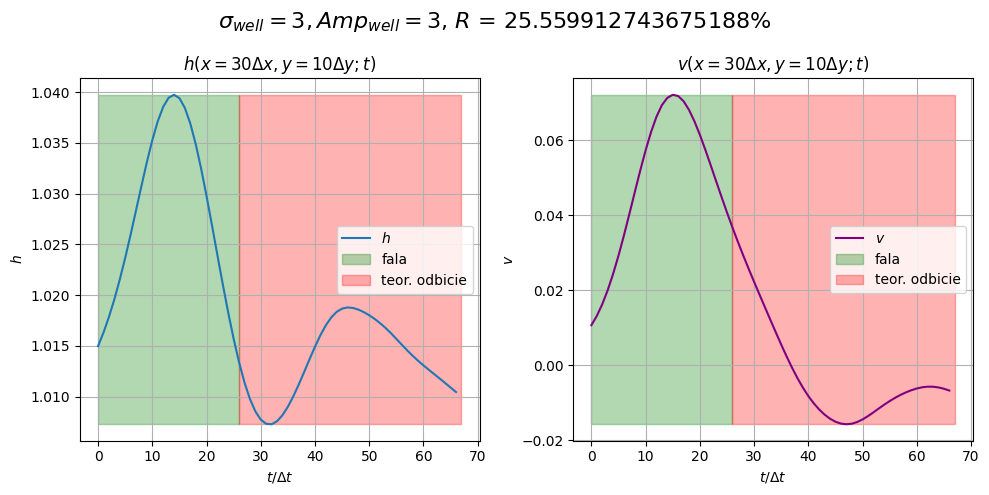

In [ ]:
wave = waveReflection(grid = (80,20), well_depth=3, well_width=3, wave_width=5)
wave.run(nt = 200)

<Figure size 1000x500 with 0 Axes>

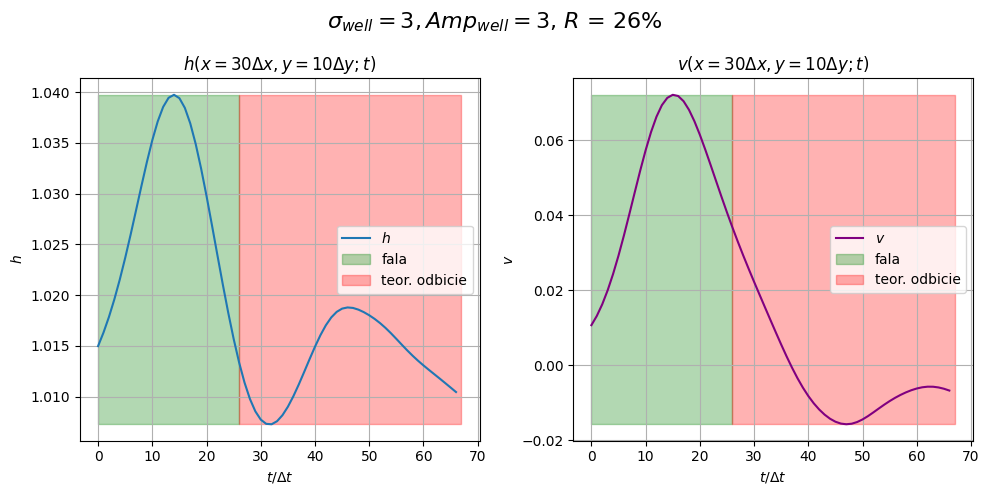

In [22]:
plot_output(wave, fname1 = 'shape_halfresolut.pdf', fname2 = 'wave_change_halfresolut.pdf')

In [6]:
widths = np.arange(1,31)/3
amps = 9.0/widths
# print(ww, wa)
Rs = []
for w, a in zip(widths, amps):
    # print(f'wid = {w}; amp = {a}')
    wave = waveReflection(grid = (80,20), well_depth=a, well_width=w, wave_width=5)
    wave.run(nt = 200)
    _, R = wave.R_factor()
    Rs.append(R)

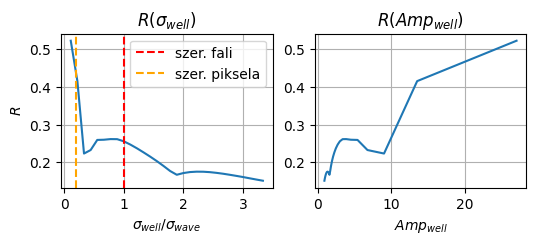

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(6,2))
Rsa = np.array(Rs)
axs[0].plot(widths/3, Rs)
axs[1].plot(amps, Rs)
axs[0].grid()
axs[1].grid()

axs[0].set_title(r"$R(\sigma_{well}$)")
axs[0].set_xlabel(r"$\sigma_{well}/\sigma_{wave}$")
axs[0].set_ylabel(r"$R$");
axs[0].axvline(x=1, label='szer. fali', color='red', linestyle='--')
axs[0].axvline(x=0.2, label='szer. piksela', color='orange', linestyle='--')
axs[0].legend()

axs[1].set_title(r"$R(Amp_{well})$")
axs[1].set_xlabel(r"$Amp_{well}$")

plt.savefig("R_half.pdf")
# axs[1].set_ylabel(r"$R$");